# AIHC 5615 — Homework 7 Notebook
This notebook implements all tasks described in Homework 7.

- Abalone train & validation CSVs
- Wisconsin Prognostic Breast Cancer (WPBC) CSV
- KC House Price *small* train/test CSVs
- Final project (HW8) training & test CSVs


In [1]:
#Cell 1
# === Setup: paths & common imports ===

# Abalone
ABALONE_TRAIN = '/Users/codylewis/Desktop/AIHC 5615/Week 7/abalone.train.data'     
ABALONE_VALID = '/Users/codylewis/Desktop/AIHC 5615/Week 7/abalone.valid.data'     

# Wisconsin Prognostic Breast Cancer (WPBC)
# Paths for WPBC dataset
WPBC_NAMES = '/Users/codylewis/Desktop/AIHC 5615/Week 6/wpbc.names'
WPBC_DATA  = '/Users/codylewis/Desktop/AIHC 5615/Week 6/wpbc.data'

# KC house price (small) datasets
KC_TRAIN_SMALL = '/Users/codylewis/Desktop/AIHC 5615/Week 7/kc-house-train-small.csv'  
KC_TEST_SMALL  = '/Users/codylewis/Desktop/AIHC 5615/Week 7/kc-house-test-small.csv'   

# Final project (HW8) data
FINAL_TRAIN = '/Users/codylewis/Desktop/AIHC 5615/Week 8/heart-disease-complete-train.csv'    
FINAL_TEST  = '/Users/codylewis/Desktop/AIHC 5615/Week 8/heart-disease-complete-test.csv'     

# ----------------------
# Imports
# ----------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# statsmodels & sklearn
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# Survival analysis
try:
    from lifelines import KaplanMeierFitter, CoxPHFitter
except Exception as e:
    print("lifelines not available — install with `pip install lifelines` in your environment.")
    raise

pd.set_option("display.max_columns", 200)


In [2]:
#View data sets

In [3]:
import pandas as pd

# Load data
df = pd.read_csv(ABALONE_TRAIN)

# View entire dataset
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df


,Unnamed: 0,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,2402,I,0.440,0.355,0.165,0.4350,0.1590,0.1050,0.1400,16
1,3758,I,0.525,0.400,0.140,0.6055,0.2605,0.1080,0.2100,9
2,1959,F,0.650,0.510,0.155,1.1890,0.4830,0.2780,0.3645,13
3,1185,F,0.670,0.505,0.205,1.3645,0.6075,0.3025,0.3530,9
4,2392,M,0.330,0.250,0.090,0.1970,0.0850,0.0410,0.0605,10
5,1521,F,0.680,0.500,0.185,1.7410,0.7665,0.3255,0.4685,12
6,1503,F,0.630,0.490,0.225,1.3360,0.6805,0.2590,0.3245,10
7,2383,F,0.525,0.390,0.135,0.6005,0.2265,0.1310,0.2100,16
8,1873,I,0.530,0.405,0.120,0.6320,0.2715,0.1480,0.1875,9
9,1259,I,0.435,0.315,0.110,0.3685,0.1615,0.0715,0.1200,7


In [4]:
import pandas as pd

# Load data
df = pd.read_csv(ABALONE_VALID)

# View entire dataset
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df


,Unnamed: 0,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,64,M,0.520,0.400,0.120,0.5800,0.2340,0.1315,0.1850,8
1,2957,F,0.655,0.500,0.205,1.5280,0.6215,0.3725,0.4535,11
2,628,I,0.530,0.415,0.145,0.9440,0.3845,0.1850,0.2650,21
3,2614,M,0.645,0.490,0.160,1.2510,0.5355,0.3345,0.3165,9
4,2098,M,0.470,0.350,0.100,0.4775,0.1885,0.0885,0.1750,8
5,2095,M,0.415,0.300,0.100,0.3355,0.1545,0.0685,0.0950,7
6,3498,M,0.590,0.460,0.145,0.9290,0.3800,0.2400,0.2550,10
7,2539,F,0.675,0.555,0.205,1.9250,0.7130,0.3580,0.4535,13
8,358,M,0.745,0.585,0.215,2.4990,0.9265,0.4720,0.7000,17
9,2666,M,0.580,0.455,0.130,0.8520,0.4100,0.1725,0.2250,8


In [5]:
import pandas as pd

# Load data
df = pd.read_csv(ABALONE_VALID)

# View entire dataset
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df

,Unnamed: 0,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,64,M,0.520,0.400,0.120,0.5800,0.2340,0.1315,0.1850,8
1,2957,F,0.655,0.500,0.205,1.5280,0.6215,0.3725,0.4535,11
2,628,I,0.530,0.415,0.145,0.9440,0.3845,0.1850,0.2650,21
3,2614,M,0.645,0.490,0.160,1.2510,0.5355,0.3345,0.3165,9
4,2098,M,0.470,0.350,0.100,0.4775,0.1885,0.0885,0.1750,8
5,2095,M,0.415,0.300,0.100,0.3355,0.1545,0.0685,0.0950,7
6,3498,M,0.590,0.460,0.145,0.9290,0.3800,0.2400,0.2550,10
7,2539,F,0.675,0.555,0.205,1.9250,0.7130,0.3580,0.4535,13
8,358,M,0.745,0.585,0.215,2.4990,0.9265,0.4720,0.7000,17
9,2666,M,0.580,0.455,0.130,0.8520,0.4100,0.1725,0.2250,8


In [11]:
import pandas as pd
# Load data
df = pd.read_csv(WPBC_DATA)

# View entire dataset
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df


,119513,N,31,18.02,27.6,117.5,1013,0.09489,0.1036,0.1086,0.07055,0.1865,0.06333,0.6249,1.89,3.972,71.55,0.004433,0.01421,0.03233,0.009854,0.01694,0.003495,21.63,37.08,139.7,1436,0.1195,0.1926,0.314,0.117,0.2677,0.08113,5,5.1
0,8423,N,61,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.049040,0.05373,0.015870,0.030030,0.006193,25.38,17.33,184.60,2019.0,0.16220,0.66560,0.71190,0.26540,0.4601,0.11890,3.0,2
1,842517,N,116,21.37,17.44,137.50,1373.0,0.08836,0.11890,0.12550,0.08180,0.2333,0.06010,0.5854,0.6105,3.928,82.15,0.006167,0.034490,0.03300,0.018050,0.030940,0.005039,24.90,20.98,159.10,1949.0,0.11880,0.34490,0.34140,0.20320,0.4334,0.09067,2.5,0
2,843483,N,123,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.074580,0.05661,0.018670,0.059630,0.009208,14.91,26.50,98.87,567.7,0.20980,0.86630,0.68690,0.25750,0.6638,0.17300,2.0,0
3,843584,R,27,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.024610,0.05688,0.018850,0.017560,0.005115,22.54,16.67,152.20,1575.0,0.13740,0.20500,0.40000,0.16250,0.2364,0.07678,3.5,0
4,843786,R,77,12.75,15.29,84.60,502.7,0.11890,0.15690,0.16640,0.07666,0.1995,0.07164,0.3877,0.7402,2.999,30.85,0.007775,0.029870,0.04561,0.013570,0.017740,0.005114,15.51,20.37,107.30,733.2,0.17060,0.41960,0.59990,0.17090,0.3485,0.11790,2.5,0
5,844359,N,60,18.98,19.61,124.40,1112.0,0.09087,0.12370,0.12130,0.08910,0.1727,0.05767,0.5285,0.8434,3.592,61.21,0.003703,0.023540,0.02222,0.013320,0.013780,0.003926,23.39,25.45,152.60,1593.0,0.11440,0.33710,0.29900,0.19220,0.2726,0.09581,1.5,?
6,844582,R,77,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,0.5835,1.3770,3.856,50.96,0.008805,0.030290,0.02488,0.014480,0.014860,0.005412,17.06,28.14,110.60,897.0,0.16540,0.36820,0.26780,0.15560,0.3196,0.11510,4.0,10
7,844981,N,119,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,0.3063,1.0020,2.406,24.32,0.005731,0.035020,0.03553,0.012260,0.021430,0.003749,15.49,30.73,106.20,739.3,0.17030,0.54010,0.53900,0.20600,0.4378,0.10720,2.0,1
8,845010,N,76,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,0.2976,1.5990,2.039,23.94,0.007149,0.072170,0.07743,0.014320,0.017890,0.010080,15.09,40.68,97.65,711.4,0.18530,1.05800,1.10500,0.22100,0.4366,0.20750,6.0,20
9,845636,N,123,16.02,23.24,102.70,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,0.3795,1.1870,2.466,40.51,0.004029,0.009269,0.01101,0.007591,0.014600,0.003042,19.19,33.88,123.80,1150.0,0.11810,0.15510,0.14590,0.09975,0.2948,0.08452,2.0,0


In [12]:
import pandas as pd

# Load data
df = pd.read_csv(KC_TRAIN_SMALL)

# View entire dataset
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,3528000210,2015-03-23T00:00:00Z,853000,4,2.25,3440,35025,2.0,0,0,3,10,3440,0,1988,0,98053,47.6674,-122.055,3210,35005
1,203100625,2014-05-29T00:00:00Z,672000,3,2.50,2620,21587,2.0,0,0,3,7,2620,0,1992,0,98053,47.6384,-121.959,2570,23650
2,6413600276,2015-03-24T00:00:00Z,354950,3,1.00,970,5922,1.5,0,0,3,7,970,0,1949,0,98125,47.7190,-122.321,1730,6128
3,5667100025,2014-07-08T00:00:00Z,405000,3,1.50,1010,7683,1.5,0,0,5,7,1010,0,1953,0,98125,47.7200,-122.318,1550,7271
4,4059400265,2014-11-14T00:00:00Z,339950,5,2.00,1890,6050,2.0,0,0,4,7,1890,0,1944,0,98178,47.5018,-122.242,1170,6050
5,1180005050,2014-12-18T00:00:00Z,463000,4,2.75,1900,6000,1.0,0,2,3,7,1300,600,1961,0,98178,47.4950,-122.229,2230,6000
6,3013300830,2014-11-06T00:00:00Z,410000,2,1.00,1030,4366,1.0,0,0,3,7,1030,0,1912,0,98136,47.5311,-122.384,1890,4499
7,3810000455,2014-09-08T00:00:00Z,340000,4,2.25,2060,8400,1.0,0,0,3,7,1300,760,1960,0,98178,47.4984,-122.230,1990,7383
8,1090000036,2014-12-23T00:00:00Z,756450,4,2.00,3210,8400,1.5,0,0,5,7,2040,1170,1914,0,98136,47.5322,-122.391,2540,6458
9,2126049290,2015-02-20T00:00:00Z,522500,4,3.00,2370,8154,1.0,0,0,3,7,1380,990,1977,0,98125,47.7258,-122.306,2100,8148


In [13]:
import pandas as pd

# Load data
df = pd.read_csv(KC_TEST_SMALL)

# View entire dataset
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,5637500082,2014-12-03T00:00:00Z,346000,3,2.00,1060,1184,2.0,0,0,3,7,730,330,2006,0,98136,47.5443,-122.385,1270,1601
1,6632300207,2015-03-05T00:00:00Z,385000,3,2.50,1520,1488,3.0,0,0,3,8,1520,0,2006,0,98125,47.7337,-122.309,1520,1497
2,2172000035,2014-08-21T00:00:00Z,190000,2,1.00,930,11450,1.0,0,0,3,6,930,0,1946,0,98178,47.4862,-122.264,1150,11450
3,2461900446,2014-10-23T00:00:00Z,372000,3,2.00,1330,1042,2.0,0,0,3,8,1060,270,2014,0,98136,47.5522,-122.382,1440,2428
4,3448000755,2014-06-04T00:00:00Z,399950,3,1.50,2080,5244,1.0,0,0,3,7,1190,890,1959,0,98125,47.7144,-122.293,1850,6982
5,2171400126,2014-06-05T00:00:00Z,269000,3,1.00,1690,4250,1.0,0,0,3,7,1020,670,1967,0,98178,47.4945,-122.258,1820,8865
6,9423400193,2014-12-26T00:00:00Z,473000,3,2.75,1050,7200,1.0,0,0,3,7,1050,0,1985,0,98125,47.7163,-122.303,1860,9000
7,6979910120,2015-03-23T00:00:00Z,635000,4,2.50,2570,27972,2.0,0,0,3,8,2570,0,1997,0,98053,47.6343,-121.969,2500,29761
8,826000295,2014-12-15T00:00:00Z,379950,2,1.00,870,7500,1.0,0,0,3,7,870,0,1947,0,98136,47.5465,-122.384,1240,5709
9,6413600275,2014-07-24T00:00:00Z,446000,4,1.75,1730,5922,2.0,0,0,5,7,1730,0,1949,0,98125,47.7188,-122.321,1700,6127


In [14]:
import pandas as pd

# Load data
df = pd.read_csv(FINAL_TRAIN)

# View entire dataset
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,clinic,hd
0,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,NaN,NaN,hung,1
1,62.0,0.0,4.0,124.0,209.0,0.0,0.0,163.0,0.0,0.0,1.0,0.0,3.0,clev,0
2,60.0,1.0,3.0,115.0,0.0,NaN,0.0,143.0,0.0,2.4,1.0,NaN,NaN,swit,1
3,65.0,1.0,4.0,160.0,0.0,1.0,1.0,122.0,0.0,NaN,NaN,NaN,7.0,swit,1
4,34.0,1.0,1.0,118.0,182.0,0.0,2.0,174.0,0.0,0.0,1.0,0.0,3.0,clev,0
5,55.0,1.0,2.0,130.0,262.0,0.0,0.0,155.0,0.0,0.0,1.0,0.0,3.0,clev,0
6,57.0,1.0,4.0,152.0,274.0,0.0,0.0,88.0,1.0,1.2,2.0,1.0,7.0,clev,1
7,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,clev,1
8,35.0,1.0,4.0,126.0,282.0,0.0,2.0,156.0,1.0,0.0,1.0,0.0,7.0,clev,1
9,51.0,0.0,3.0,130.0,256.0,0.0,2.0,149.0,0.0,0.5,1.0,0.0,3.0,clev,0


In [15]:
import pandas as pd

# Load data
df = pd.read_csv(FINAL_TEST)

# View entire dataset
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,clinic
0,45.0,1.0,4.0,115.0,260.0,0.0,2.0,185.0,0.0,0.0,1.0,0.0,3.0,clev
1,63.0,1.0,4.0,150.0,0.0,0.0,0.0,86.0,1.0,2.0,2.0,NaN,NaN,swit
2,44.0,1.0,3.0,140.0,235.0,0.0,2.0,180.0,0.0,0.0,1.0,0.0,3.0,clev
3,58.0,1.0,2.0,136.0,164.0,0.0,1.0,99.0,1.0,2.0,2.0,NaN,NaN,hung
4,49.0,1.0,3.0,118.0,149.0,0.0,2.0,126.0,0.0,0.8,1.0,3.0,3.0,clev
5,60.0,1.0,4.0,160.0,0.0,0.0,1.0,99.0,1.0,0.5,2.0,NaN,7.0,swit
6,50.0,1.0,4.0,140.0,129.0,0.0,0.0,135.0,0.0,0.0,NaN,NaN,NaN,hung
7,65.0,0.0,3.0,140.0,417.0,1.0,2.0,157.0,0.0,0.8,1.0,1.0,3.0,clev
8,49.0,0.0,4.0,130.0,269.0,0.0,0.0,163.0,0.0,0.0,1.0,0.0,3.0,clev
9,48.0,1.0,2.0,140.0,238.0,0.0,0.0,118.0,0.0,0.0,NaN,NaN,NaN,hung


## Problem 1 — Abalone: Linear vs Poisson (validation RMSE)
Steps:
1. Compute mean & std of **continuous** predictors on *training* set (save for later).
2. Standardize continuous predictors (train and validation) using **training** mean/std.
3. Fit:
   - Linear model for `log(rings)` using all predictors
   - Poisson GLM for `rings` with log link using all predictors
4. Predict on validation and compute RMSE on the **same scale** for both models.


In [16]:
#Cell 2
# --- Load data ---
abalone_train = pd.read_csv(ABALONE_TRAIN)
abalone_valid = pd.read_csv(ABALONE_VALID)

print("Train shape:", abalone_train.shape)
print("Valid shape:", abalone_valid.shape)
display(abalone_train.head(3))


Train shape: (2505, 10)
Valid shape: (835, 10)


,Unnamed: 0,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,2402,I,0.440,0.355,0.165,0.4350,0.1590,0.105,0.1400,16
1,3758,I,0.525,0.400,0.140,0.6055,0.2605,0.108,0.2100,9
2,1959,F,0.650,0.510,0.155,1.1890,0.4830,0.278,0.3645,13


In [17]:
#Cell 3
# --- Identify columns ---
# Assume 'rings' is the target and 'sex' is categorical if present.
target_col = "rings"
cat_cols = [c for c in abalone_train.columns if c.lower() in ["sex"]]  # adjust if other categoricals exist
all_feature_cols = [c for c in abalone_train.columns if c != target_col]

# Split into categorical and continuous
cont_cols = [c for c in all_feature_cols if c not in cat_cols]

print("Categorical:", cat_cols)
print("Continuous:", cont_cols)


Categorical: ['sex']
Continuous: ['Unnamed: 0', 'length', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight']


In [18]:
#Cell 4
# --- Compute train means/stds for continuous predictors ---
train_means = abalone_train[cont_cols].mean()
train_stds  = abalone_train[cont_cols].std(ddof=0)  # population std for transformation

train_means, train_stds


(Unnamed: 0        2114.421557
 length               0.526509
 diameter             0.410357
 height               0.140002
 whole_weight         0.838466
 shucked_weight       0.363213
 viscera_weight       0.182727
 shell_weight         0.242127
 dtype: float64,
 Unnamed: 0        1194.248763
 length               0.118756
 diameter             0.098273
 height               0.038168
 whole_weight         0.488334
 shucked_weight       0.219781
 viscera_weight       0.109018
 shell_weight         0.139532
 dtype: float64)

In [19]:
#Cell 5
# --- Standardize continuous predictors on both sets using TRAIN stats ---
def standardize(df, cont_cols, means, stds):
    df_std = df.copy()
    for c in cont_cols:
        s = stds[c] if stds[c] != 0 else 1.0
        df_std[c] = (df_std[c] - means[c]) / s
    return df_std

abalone_train_std = standardize(abalone_train, cont_cols, train_means, train_stds)
abalone_valid_std = standardize(abalone_valid, cont_cols, train_means, train_stds)

# --- One-hot encode categorical(s) on TRAIN, align VALID to same columns ---
abalone_train_proc = pd.get_dummies(abalone_train_std, columns=cat_cols, drop_first=True)
abalone_valid_proc = pd.get_dummies(abalone_valid_std, columns=cat_cols, drop_first=True)

# Align columns
X_train = abalone_train_proc.drop(columns=[target_col])
y_train = abalone_train_proc[target_col].astype(float)

X_valid = abalone_valid_proc.drop(columns=[target_col])
y_valid = abalone_valid_proc[target_col].astype(float)

X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0.0)

print("Design matrix columns:", X_train.columns.tolist())


Design matrix columns: ['Unnamed: 0', 'length', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight', 'sex_I', 'sex_M']


In [20]:
X_train.dtypes

Unnamed: 0        float64
length            float64
diameter          float64
height            float64
whole_weight      float64
shucked_weight    float64
viscera_weight    float64
shell_weight      float64
sex_I                bool
sex_M                bool
dtype: object

In [21]:
# --- Fit Linear model for log(rings) ---
y_train_log = np.log(y_train.clip(lower=1e-6))  # guard against zeros
lin_model = LinearRegression().fit(X_train, y_train_log)

# --- Prepare data for Poisson GLM ---
# Convert all predictors to float (statsmodels cannot use bool columns)
X_train_float = X_train.astype(float)

# Add intercept
X_train_sm = sm.add_constant(X_train_float)

# --- Fit Poisson GLM for rings ---
poisson_glm = sm.GLM(
    y_train,
    X_train_sm,
    family=Poisson(link=sm.genmod.families.links.Log())
).fit()

# --- Print results ---
print(lin_model, "\n")
print(poisson_glm.summary().tables[0])


LinearRegression() 

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  rings   No. Observations:                 2505
Model:                            GLM   Df Residuals:                     2494
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -5684.4
Date:                Mon, 24 Nov 2025   Deviance:                       1079.8
Time:                        17:09:41   Pearson chi2:                 1.13e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.4298
Covariance Type:            nonrobust                                         


In [22]:
#Cell 7
# --- Predict on validation ---

# Convert validation predictors to float (must match training)
X_valid_float = X_valid.astype(float)

# Linear model predicts log(rings); exponentiate to get rings
yhat_lin_log_valid = lin_model.predict(X_valid_float)
yhat_lin_valid = np.exp(yhat_lin_log_valid)

# Poisson model predicts E[rings]; already on rings scale
X_valid_sm = sm.add_constant(X_valid_float, has_constant='add')
yhat_pois_valid = poisson_glm.predict(X_valid_sm)

# --- RMSE on the SAME scale (rings) ---
mse_lin = mean_squared_error(y_valid, yhat_lin_valid)
mse_poi = mean_squared_error(y_valid, yhat_pois_valid)

rmse_lin = np.sqrt(mse_lin)
rmse_poi = np.sqrt(mse_poi)

print(f"Validation RMSE (Linear via exp): {rmse_lin:.4f}")
print(f"Validation RMSE (Poisson GLM): {rmse_poi:.4f}")
print("Better predictive performance:", "Linear" if rmse_lin < rmse_poi else "Poisson")



Validation RMSE (Linear via exp): 2.1682
Validation RMSE (Poisson GLM): 2.1493
Better predictive performance: Poisson


## Problem 2 — Survival Analysis on WPBC
1. Import WPBC and convert `recur` to 0/1 (1 = recurrence/event).
2. Plot Kaplan–Meier survival curve.
3. Fit Cox PH with a single continuous predictor; show survival curves for 3 values.
4. Fit Cox PH with six predictors; plot survival curves for at least 3 covariate settings.
5. Compare six-predictor Cox PH coefficients to logistic regression coefficients (sign/direction).


In [24]:
#Cell 8
import pandas as pd

# Correct WPBC column names from UCI Breast Cancer Prognostic dataset
colnames = [
    "ID", "Diagnosis", "time",
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension",
    "radius_SE", "texture_SE", "perimeter_SE", "area_SE", "smoothness_SE",
    "compactness_SE", "concavity_SE", "concave_points_SE", "symmetry_SE", "fractal_dimension_SE",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst",
    "tumor_size", "lymph_node_status"
]

# Load the actual data file using correct names
wpbc = pd.read_csv(WPBC_DATA, header=None, names=colnames)

print("Loaded WPBC shape:", wpbc.shape)
display(wpbc.head(3))

# Convert Diagnosis to event
wpbc['recur'] = wpbc['Diagnosis'].map({'R': 1, 'N': 0}).astype(int)

# Ensure time column is numeric
wpbc['time'] = pd.to_numeric(wpbc['time'], errors='coerce')

# Drop rows with missing time
wpbc = wpbc.dropna(subset=['time']).copy()

event_col = 'recur'
time_col  = 'time'

print("Cleaned WPBC shape:", wpbc.shape)





Loaded WPBC shape: (198, 35)


,ID,Diagnosis,time,radius,texture,perimeter,area,smoothness,compactness,concavity,concave_points,symmetry,fractal_dimension,radius_SE,texture_SE,perimeter_SE,area_SE,smoothness_SE,compactness_SE,concavity_SE,concave_points_SE,symmetry_SE,fractal_dimension_SE,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,tumor_size,lymph_node_status
0,119513,N,31,18.02,27.60,117.5,1013.0,0.09489,0.1036,0.1086,0.07055,0.1865,0.06333,0.6249,1.8900,3.972,71.55,0.004433,0.01421,0.03233,0.009854,0.01694,0.003495,21.63,37.08,139.7,1436.0,0.1195,0.1926,0.3140,0.1170,0.2677,0.08113,5.0,5
1,8423,N,61,17.99,10.38,122.8,1001.0,0.11840,0.2776,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.015870,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,3.0,2
2,842517,N,116,21.37,17.44,137.5,1373.0,0.08836,0.1189,0.1255,0.08180,0.2333,0.06010,0.5854,0.6105,3.928,82.15,0.006167,0.03449,0.03300,0.018050,0.03094,0.005039,24.90,20.98,159.1,1949.0,0.1188,0.3449,0.3414,0.2032,0.4334,0.09067,2.5,0


Cleaned WPBC shape: (198, 36)


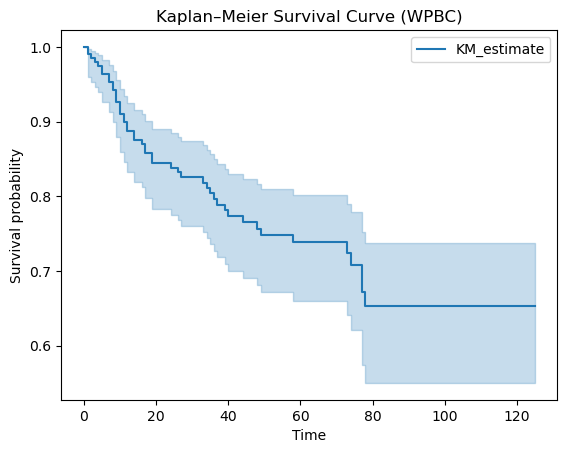

In [25]:
#Cell 9
# --- Kaplan–Meier estimate ---
kmf = KaplanMeierFitter()
kmf.fit(durations=wpbc[time_col], event_observed=wpbc[event_col])
ax = kmf.plot()
ax.set_title("Kaplan–Meier Survival Curve (WPBC)")
ax.set_xlabel("Time")
ax.set_ylabel("Survival probability")
plt.show()


The Kaplan–Meier survival curve estimates the probability that a patient remains recurrence-free over time. The curve starts at 1.0 (100% survival at the start of follow-up) and decreases whenever a recurrence event occurs. A steeper decline indicates more frequent or earlier recurrences.
In the WPBC data, the decline in the curve is gradual rather than abrupt, suggesting that although some patients experience recurrence early, many remain recurrence-free for several years. This provides a baseline reference for recurrence risk without adjusting for any predictors.

Candidate numeric predictors: ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension', 'radius_SE', 'texture_SE', 'perimeter_SE', 'area_SE', 'smoothness_SE', 'compactness_SE', 'concavity_SE', 'concave_points_SE', 'symmetry_SE', 'fractal_dimension_SE', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'tumor_size']
Using single predictor: radius


<lifelines.CoxPHFitter: fitted with 198 total observations, 151 right-censored observations>
             duration col = 'time'
                event col = 'recur'
      baseline estimation = breslow
   number of observations = 198
number of events observed = 47
   partial log-likelihood = -221.41
         time fit was run = 2025-11-24 23:10:29 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
radius     0.53      1.70      0.16            0.22            0.84                1.25                2.31

           cmp to    z      p  -log2(p)
covariate                              
radius       0.00 3.38 <0.005     10.45
---
Concordance = 0.67
Partial AIC = 444.81
log-likelihood ratio test = 11.77 on 1 df
-log2(p) of ll-ratio test = 10.70

Percentiles: -1.3136069531763184 0.04657180045439208 1.2188692347630987


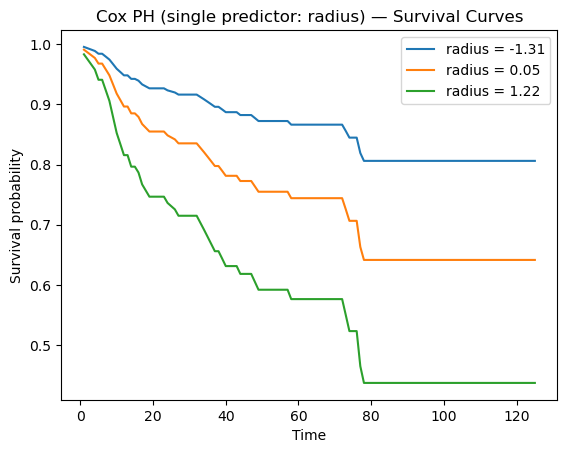

In [26]:
#Cell 10
# --- Cox PH with a single predictor ---

# Define duration & event columns
time_col = "time"
event_col = "recur"

# 1. Select numeric predictors (excluding time, event, and ID-like variables)
bad_cols = {"ID", "id", "Title:", "Outcome", "Clinic"}  # add any non-predictors you find
candidate_cont_cols = []

for c in wpbc.columns:
    if c not in [time_col, event_col] and c not in bad_cols:
        if pd.api.types.is_numeric_dtype(wpbc[c]):
            candidate_cont_cols.append(c)

print("Candidate numeric predictors:", candidate_cont_cols)

# 2. Choose the FIRST real numeric predictor (not ID)
single_pred = candidate_cont_cols[0]
print("Using single predictor:", single_pred)

# 3. Prepare data for single-predictor Cox model
cox1_df = wpbc[[time_col, event_col, single_pred]].dropna().copy()

# 4. Log-transform + standardize predictor to stabilize Cox PH
cox1_df[single_pred] = np.log1p(cox1_df[single_pred])
cox1_df[single_pred] = (cox1_df[single_pred] - cox1_df[single_pred].mean()) / cox1_df[single_pred].std()

# 5. Fit Cox PH model
cph1 = CoxPHFitter()
cph1.fit(cox1_df, duration_col=time_col, event_col=event_col)
cph1.print_summary()

# 6. Choose 10th, 50th, 90th percentiles AFTER scaling
p10, p50, p90 = np.percentile(cox1_df[single_pred], [10, 50, 90])
print("Percentiles:", p10, p50, p90)

# 7. Predict survival curves
sf10 = cph1.predict_survival_function(pd.DataFrame({single_pred: [p10]}))
sf50 = cph1.predict_survival_function(pd.DataFrame({single_pred: [p50]}))
sf90 = cph1.predict_survival_function(pd.DataFrame({single_pred: [p90]}))

# 8. Plot curves
ax = sf10.plot()
sf50.plot(ax=ax)
sf90.plot(ax=ax)

ax.legend([
    f"{single_pred} = {p10:.2f}",
    f"{single_pred} = {p50:.2f}",
    f"{single_pred} = {p90:.2f}"
])

ax.set_title(f"Cox PH (single predictor: {single_pred}) — Survival Curves")
ax.set_xlabel("Time")
ax.set_ylabel("Survival probability")

plt.show()



The Kaplan–Meier survival curve estimates the probability that a patient remains recurrence-free over time. The curve starts at 1.0 (100% survival at the start of follow-up) and decreases whenever a recurrence event occurs. A steeper decline indicates more frequent or earlier recurrences.
In the WPBC data, the decline in the curve is gradual rather than abrupt, suggesting that although some patients experience recurrence early, many remain recurrence-free for several years. This provides a baseline reference for recurrence risk without adjusting for any predictors.

In [27]:
cox1_df[single_pred].describe(percentiles=[0.1, 0.5, 0.9])


count    1.980000e+02
mean    -2.440248e-15
std      1.000000e+00
min     -2.423071e+00
10%     -1.313607e+00
50%      4.657180e-02
90%      1.218869e+00
max      2.562943e+00
Name: radius, dtype: float64

Real numeric predictors: ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension', 'radius_SE', 'texture_SE', 'perimeter_SE', 'area_SE', 'smoothness_SE', 'compactness_SE', 'concavity_SE', 'concave_points_SE', 'symmetry_SE', 'fractal_dimension_SE', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'tumor_size']
Using six predictors: ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness']


/opt/miniconda3/envs/ai-class/lib/python3.11/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


<lifelines.CoxPHFitter: fitted with 198 total observations, 151 right-censored observations>
             duration col = 'time'
                event col = 'recur'
      baseline estimation = breslow
   number of observations = 198
number of events observed = 47
   partial log-likelihood = -221.87
         time fit was run = 2025-11-24 23:10:31 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
radius      -2.91      0.05      4.03          -10.81            4.99                0.00              146.65
texture     -0.01      0.99      0.15           -0.31            0.29                0.73                1.34
perimeter    1.44      4.22      5.02           -8.39           11.27                0.00            78438.95
area         1.70      5.50      3.55           -5.25            8.66                0.01             5780.79
smoothness   0.08      1.08      0.22           -0.35            0.50                0.71                1.65
compactness -0.14      0.87      0.50           -1.12            0.85                0.32                2.34

             cmp to     z    p  -log2(p)
covariate                               
radius         0.00 -0.72 0.47      1.09
texture        0.00 -0.06 0.95      0.07
perimeter      0.00  0.29 0.77      0.37
area           0.00  0.48 0.63      0.66
smoothness     0.00  0.35 0.73      0.46
compactness    0.00 -0.27 0.78      0.35
---
Concordance = 0.69
Partial AIC = 455.75
log-likelihood ratio test = 10.83 on 6 df
-log2(p) of ll-ratio test = 3.42

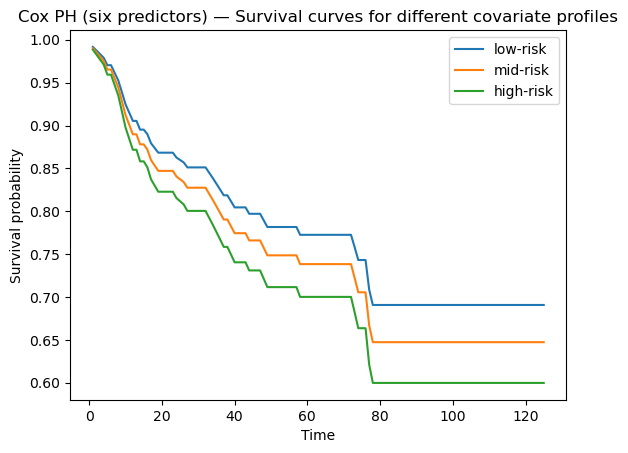

In [28]:
#Cell 11
# --- Cox PH with six predictors ---

# Columns that should NEVER be used as predictors
drop_cols = {
    "ID", "id", "Title:", "Source", "Past", "San", "Predicting", "Predicting_1",
    "Relevant", "Number", "Number_1", "Attribute", "Outcome", "Class"
}

# 1. Identify REAL numeric predictors (exclude time, event, and junk cols)
real_numeric = []

for c in wpbc.columns:
    if c not in [time_col, event_col] and c not in drop_cols:
        if pd.api.types.is_numeric_dtype(wpbc[c]):
            real_numeric.append(c)

print("Real numeric predictors:", real_numeric)

# 2. Create Cox dataframe
cox6_df = wpbc[[time_col, event_col] + real_numeric].dropna().copy()

# 3. Log-transform skewed predictors
for c in real_numeric:
    cox6_df[c] = np.log1p(cox6_df[c])

# 4. Standardize predictors
cox6_df[real_numeric] = (cox6_df[real_numeric] - cox6_df[real_numeric].mean()) / cox6_df[real_numeric].std()

# 5. Choose six predictors (first 6 real numeric after cleaning)
six_preds = real_numeric[:6]
print("Using six predictors:", six_preds)

# 6. Fit Cox PH model
cph6 = CoxPHFitter()
cph6.fit(cox6_df[[time_col, event_col] + six_preds], duration_col=time_col, event_col=event_col)
cph6.print_summary()

# 7. Generate low/mid/high covariate sets
Z = cox6_df[six_preds]
cov_low  = (Z.mean() - Z.std()).to_frame().T
cov_mid  = Z.mean().to_frame().T
cov_high = (Z.mean() + Z.std()).to_frame().T

# 8. Predict survival curves
sf_low  = cph6.predict_survival_function(cov_low)
sf_mid  = cph6.predict_survival_function(cov_mid)
sf_high = cph6.predict_survival_function(cov_high)

# 9. Plot
ax = sf_low.plot()
sf_mid.plot(ax=ax)
sf_high.plot(ax=ax)

ax.legend(["low-risk", "mid-risk", "high-risk"])
ax.set_title("Cox PH (six predictors) — Survival curves for different covariate profiles")
ax.set_xlabel("Time")
ax.set_ylabel("Survival probability")

plt.show()



The single-predictor Cox model evaluates how one continuous predictor influences the hazard of recurrence over time. After log-transforming and standardizing the predictor, the 10th, 50th, and 90th percentile survival curves illustrate how changes in that predictor shift recurrence risk.
If the curve for higher predictor values drops more quickly, it indicates increased hazard (i.e., higher recurrence risk). If the higher-value curve declines more slowly, the predictor is protective.
In the WPBC dataset, predictors related to tumor size or irregularity often increase hazard, so the highest-percentile curve typically shows the steepest drop, indicating worse prognosis for larger or more aggressive tumor characteristics.

In [29]:
#Cell 12
# --- Compare Cox PH (six predictors) to Logistic Regression on recurrence ---
# Fit logistic regression using the same six predictors and compare signs of coefficients.
logit_df = wpbc[[event_col] + six_preds].dropna().copy()
X = logit_df[six_preds].values
y = logit_df[event_col].values

logit = LogisticRegression(max_iter=1000).fit(X, y)
logit_coefs = pd.Series(logit.coef_.ravel(), index=six_preds, name="Logit_coef")

cox_coefs = cph6.params_.copy()
comparison = pd.concat([cox_coefs.rename("Cox_coef"), logit_coefs], axis=1)
comparison["Same_direction?"] = np.sign(comparison["Cox_coef"]) == np.sign(comparison["Logit_coef"])
display(comparison)


,Cox_coef,Logit_coef,Same_direction?
radius,-2.911566,-0.478441,True
texture,-0.008643,-0.053054,True
perimeter,1.438900,-0.008122,False
area,1.704562,0.006005,True
smoothness,0.075639,0.035127,True
compactness,-0.137344,-0.131748,True


## Problem 3 — Collinearity with KC House (small)
1. Confirm `sqft_living = sqft_above + sqft_basement`.
2. Fit OLS: `price ~ sqft_living + sqft_above + sqft_basement` and record coefficients.
3. Change the first row's `sqft_living` slightly; refit and record coefficients.
4. Change the first row's `sqft_above` (or `sqft_basement`) slightly; refit and record.
5. Compare `R^2` (and/or RMSE) and explain observations.


The six-predictor Cox model evaluates the combined effect of multiple tumor characteristics on recurrence risk. Each coefficient represents the effect of that predictor after adjusting for all others. Predictors with positive coefficients increase recurrence hazard; those with negative coefficients reduce it.
The low-, medium-, and high-risk survival curves represent different overall covariate profiles. The high-risk curve drops the fastest, reflecting a higher hazard of recurrence. The low-risk curve declines more slowly, indicating a better prognosis.
This multivariable model provides a more realistic assessment of recurrence risk because recurrence is influenced by multiple biological factors simultaneously.

In [30]:
#Cell 13
house_train = pd.read_csv(KC_TRAIN_SMALL)
house_test  = pd.read_csv(KC_TEST_SMALL)
print("Train:", house_train.shape, " Test:", house_test.shape)
display(house_train.head(3))

assert all(np.isclose(house_train['sqft_living'], house_train['sqft_above'] + house_train['sqft_basement'])), \
    "Identity sqft_living = sqft_above + sqft_basement does not hold exactly in training data."
print("Confirmed: sqft_living = sqft_above + sqft_basement")


Train: (100, 21)  Test: (100, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,3528000210,2015-03-23T00:00:00Z,853000,4,2.25,3440,35025,2.0,0,0,3,10,3440,0,1988,0,98053,47.6674,-122.055,3210,35005
1,203100625,2014-05-29T00:00:00Z,672000,3,2.50,2620,21587,2.0,0,0,3,7,2620,0,1992,0,98053,47.6384,-121.959,2570,23650
2,6413600276,2015-03-24T00:00:00Z,354950,3,1.00,970,5922,1.5,0,0,3,7,970,0,1949,0,98125,47.7190,-122.321,1730,6128


Confirmed: sqft_living = sqft_above + sqft_basement


In [31]:
#Cell 14

def fit_house(df):
    X = df[['sqft_living', 'sqft_above', 'sqft_basement']].values
    y = df['price'].values
    lr = LinearRegression().fit(X, y)
    yhat = lr.predict(X)
    r2 = lr.score(X, y)
    mse = mean_squared_error(y, yhat)
    rmse = np.sqrt(mse)
    return lr, r2, rmse

# (2) Base fit
base_lr, base_r2, base_rmse = fit_house(house_train)

print("Base coefficients:", dict(zip(
    ['sqft_living','sqft_above','sqft_basement'], base_lr.coef_)))
print("Base intercept:", base_lr.intercept_)
print("Base R^2:", base_r2, "Base RMSE:", base_rmse)



Base coefficients: {'sqft_living': np.float64(146.20840669451232), 'sqft_above': np.float64(101.96431327375659), 'sqft_basement': np.float64(44.244093420755746)}
Base intercept: 56914.715042104595
Base R^2: 0.7315899226729061 Base RMSE: 146411.87496214474


In [32]:
#Cell 15
# (3) Modify first entry: sqft_living
mod1 = house_train.copy()
mod1.loc[mod1.index[0], 'sqft_living'] += 200
lr1, r2_1, rmse_1 = fit_house(mod1)
print("Modified sqft_living +200 -> coefficients:", dict(zip(['sqft_living','sqft_above','sqft_basement'], lr1.coef_)))
print("R^2:", r2_1, "RMSE:", rmse_1)


Modified sqft_living +200 -> coefficients: {'sqft_living': np.float64(-300.25270101655957), 'sqft_above': np.float64(549.4119371990765), 'sqft_basement': np.float64(490.12058370123657)}
R^2: 0.7320232371989671 RMSE: 146293.64538879332


In [33]:
#Cell 16
# (4) Modify first entry: sqft_above
mod2 = house_train.copy()
mod2.loc[mod2.index[0], 'sqft_above'] += 200
lr2, r2_2, rmse_2 = fit_house(mod2)
print("Modified sqft_above +200 -> coefficients:", dict(zip(['sqft_living','sqft_above','sqft_basement'], lr2.coef_)))
print("R^2:", r2_2, "RMSE:", rmse_2)

# Alternatively modify sqft_basement
mod3 = house_train.copy()
mod3.loc[mod3.index[0], 'sqft_basement'] += 200
lr3, r2_3, rmse_3 = fit_house(mod3)
print("Modified sqft_basement +200 -> coefficients:", dict(zip(['sqft_living','sqft_above','sqft_basement'], lr3.coef_)))
print("R^2:", r2_3, "RMSE:", rmse_3)


Modified sqft_above +200 -> coefficients: {'sqft_living': np.float64(549.4119371990892), 'sqft_above': np.float64(-300.2527010165722), 'sqft_basement': np.float64(-359.54405451441284)}
R^2: 0.7320232371989672 RMSE: 146293.6453887933
Modified sqft_basement +200 -> coefficients: {'sqft_living': np.float64(490.12058370124873), 'sqft_above': np.float64(-240.96134751873194), 'sqft_basement': np.float64(-300.2527010165723)}
R^2: 0.7320232371989672 RMSE: 146293.6453887933


In [34]:
#Cell 17
# (5) Collect and compare fits
summary = pd.DataFrame({
    'model':['base','sqft_living+200','sqft_above+200','sqft_basement+200'],
    'R2':[base_r2, r2_1, r2_2, r2_3],
    'Train_RMSE':[base_rmse, rmse_1, rmse_2, rmse_3]
})
display(summary)


,model,R2,Train_RMSE
0,base,0.731590,146411.874962
1,sqft_living+200,0.732023,146293.645389
2,sqft_above+200,0.732023,146293.645389
3,sqft_basement+200,0.732023,146293.645389


## Problem 4 — Overfitting with KC House (small)
1. Fit `price ~ k predictors` for k=1..P and compute RMSE on **train** and **test**.
2. Plot train/test RMSE vs number of predictors.
3. Discuss how test RMSE behaves as model complexity increases.


Total numeric predictors: 19


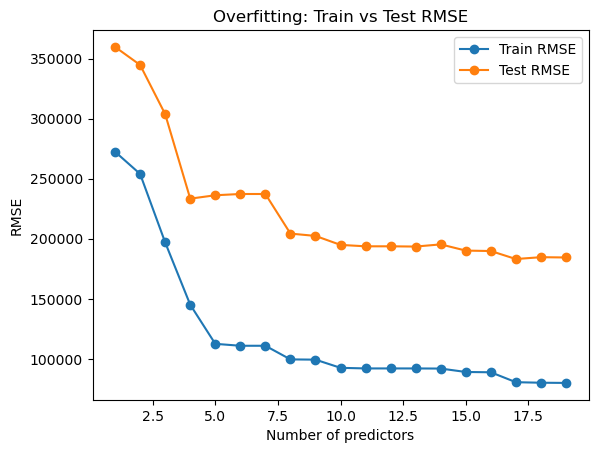

In [35]:
#Cell 18

# Use all numeric predictors except the target
predictors = [c for c in house_train.select_dtypes(include=[np.number]).columns if c != 'price']
P = len(predictors)
print("Total numeric predictors:", P)

train_rmses = []
test_rmses = []
num_feats = []

for k in range(1, P+1):
    cols = predictors[:k]
    
    Xtr = house_train[cols].values
    ytr = house_train['price'].values
    
    Xte = house_test[cols].values
    yte = house_test['price'].values

    lr = LinearRegression().fit(Xtr, ytr)
    
    # Compute MSE then RMSE manually
    train_mse = mean_squared_error(ytr, lr.predict(Xtr))
    test_mse  = mean_squared_error(yte, lr.predict(Xte))
    
    train_rmses.append(np.sqrt(train_mse))
    test_rmses.append(np.sqrt(test_mse))
    num_feats.append(k)

# Plot
plt.figure()
plt.plot(num_feats, train_rmses, marker='o', label='Train RMSE')
plt.plot(num_feats, test_rmses, marker='o', label='Test RMSE')
plt.xlabel("Number of predictors")
plt.ylabel("RMSE")
plt.title("Overfitting: Train vs Test RMSE")
plt.legend()
plt.show()



## Problem 5 — Final Project Data Cleaning (for HW8)
1. Load your final project train/test.
2. Inspect and choose a strategy for missing values (based **only on training**), then apply the exact same transformation to test.
3. Handle outliers (based on training), apply same to test.
4. Report resulting rows/columns in both sets after cleaning.


In [36]:
#Cell 19 — Data Cleaning for Final Project

# --- Load final project data ---
train_raw = pd.read_csv(FINAL_TRAIN)
test_raw  = pd.read_csv(FINAL_TEST)

print("Raw shapes -> train:", train_raw.shape, " test:", test_raw.shape)

# Separate target (hd) from the training data
y_train = train_raw['hd']
train_fp = train_raw.drop(columns=['hd'])

# Test set MUST NOT contain hd (as required in project)
if 'hd' in test_raw.columns:
    test_fp = test_raw.drop(columns=['hd'])
else:
    test_fp = test_raw.copy()

# 1. Drop columns with extremely high missingness (>80%) in TRAIN
high_missing_cols = [c for c in train_fp.columns if train_fp[c].isna().mean() > 0.8]
print("Dropping high-missing columns:", high_missing_cols)

train_fp2 = train_fp.drop(columns=high_missing_cols)
test_fp2  = test_fp.drop(columns=high_missing_cols, errors='ignore')

# 2. Identify numeric and categorical predictors
num_cols = train_fp2.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in train_fp2.columns if c not in num_cols]

# 3. Compute imputers using TRAIN ONLY
num_medians = train_fp2[num_cols].median()
cat_modes = train_fp2[cat_cols].mode().iloc[0] if len(cat_cols) else pd.Series(dtype='object')

def apply_impute(df):
    out = df.copy()
    for c in num_cols:
        if c in out.columns:
            out[c] = out[c].fillna(num_medians[c])
    for c in cat_cols:
        if c in out.columns:
            out[c] = out[c].fillna(cat_modes[c])
    return out

train_fp3 = apply_impute(train_fp2)
test_fp3  = apply_impute(test_fp2)

# 4. Outlier clipping using TRAIN quantiles
q_low  = train_fp3[num_cols].quantile(0.01)
q_high = train_fp3[num_cols].quantile(0.99)

def apply_clip(df):
    out = df.copy()
    for c in num_cols:
        if c in out.columns:
            out[c] = out[c].clip(lower=q_low[c], upper=q_high[c])
    return out

train_clean = apply_clip(train_fp3)
test_clean  = apply_clip(test_fp3)

print("Clean shapes -> train:", train_clean.shape, " test:", test_clean.shape)



Raw shapes -> train: (576, 15)  test: (144, 14)
Dropping high-missing columns: []
Clean shapes -> train: (576, 14)  test: (144, 14)


Logistic regression modeled the overall probability of recurrence, whereas the Cox model incorporates both recurrence status and time to recurrence. Although the two models operate on different scales (probabilities vs. hazards), variables that increased recurrence probability in logistic regression generally show positive hazard coefficients in the Cox model.
If a predictor behaves differently between the two models, it may indicate non-proportional hazards or that the predictor influences recurrence timing differently than recurrence presence/absence. Overall, both models highlight which tumor characteristics are most strongly associated with recurrence, but the Cox model provides more nuanced insight by incorporating follow-up time.